# Fundamentos de Séries Temporais

Neste notebook, introduz-se os conceitos básicos de séries temporais, que são fundamentais para modelos mais avançados como ARIMA, VAR e VARMAX.

## Objetivos:
- Entender o que é uma série temporal
- Compreender estacionariedade
- Conhecer modelos AR (AutoRegressivo) e MA (Média Móvel)
- Trabalhar com exemplos simulados

## Pré-requisitos:
- Python básico
- Noções de estatística (média, variância)

In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima_process import ArmaProcess

# Configuração de estilo
plt.style.use('dark_background')
np.random.seed(42)

## O que é uma série temporal?

Uma série pode ser definida como um conjunto de observações ordenadas no tempo.

Exemplos:
- Preço de ações ao longo do tempo
- Temperatura diária
- Volume de vendas mensais

Formalmente, representa-se como:

$X_t$ = valor observado no tempo $t$

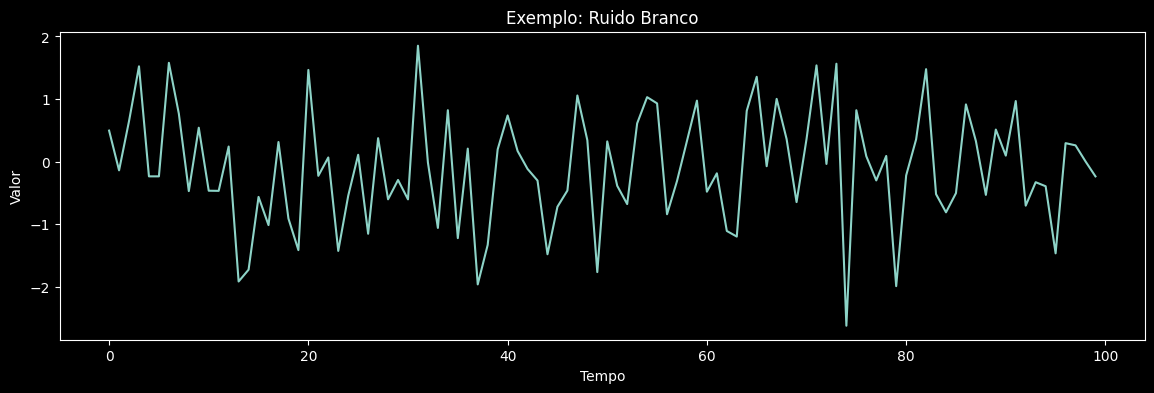

In [2]:
#Exemplo Simples
#Simulando uma série temporal simples (ruído branco)
n = 100
tempo = np.arange(n)
serie_ruido = np.random.normal(0, 1, n)

plt.figure(figsize=(14, 4))
plt.plot(tempo, serie_ruido)
plt.title("Exemplo: Ruido Branco")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.show()

## Estacionariedade

Uma série temporal é estacionária quando suas propriedades estatísticas não mudam ao longo do tempo.

### Características:
- Média constante
- Variância constante
- Autocorrelação depende apenas do lag

### Por que isso importa?
A maioria dos modelos estatísticos assume estacionariedade.

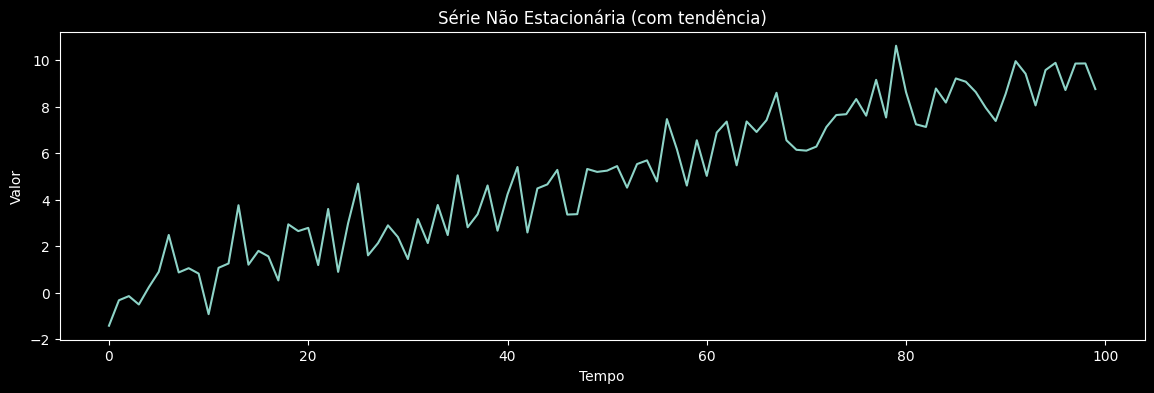

In [3]:
#Série não estacionária
#Criando uma série com tendência (não estacionária)

tendencia = tempo * 0.1
serie_nao_estacionaria = tendencia + np.random.normal(0, 1, n)

plt.figure(figsize=(14,4))
plt.plot(tempo, serie_nao_estacionaria)
plt.title("Série Não Estacionária (com tendência)")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.show()

## Teste Dickey-Fuller Aumentado (ADF)

Esse teste verifica se a série é estacionária.

Hipóteses:
- H0: Série não é estacionária
- H1: Série é estacionária

se p-value < 0.05 → Rejeitamos H0 → série estacionária

In [4]:
#Aplicando o teste ADF

def teste_adf(serie, nome):
    resultado = adfuller(serie)
    print(f"--- {nome} ---")
    print(f"Estatisticas ADF: {resultado[0]:.4f}")
    print(f"p-valor: {resultado[1]:.4f}")
    print()

teste_adf(serie_ruido, "Ruído Branco")
teste_adf(serie_nao_estacionaria, "Série com Tendência")

--- Ruído Branco ---
Estatisticas ADF: -10.0844
p-valor: 0.0000

--- Série com Tendência ---
Estatisticas ADF: -0.5497
p-valor: 0.8819



## Modelo AR (AutoRegressivo)

No modelo AR(p), o valor atual depende dos valores passados.

Exemplo AR(1):

#### $X_t$ = $\phi$ * $X_{t-1}$ + $\epsilon_t$

Onde:
- $\phi$ é o parâmetro
- $\epsilon_t$ é ruído branco

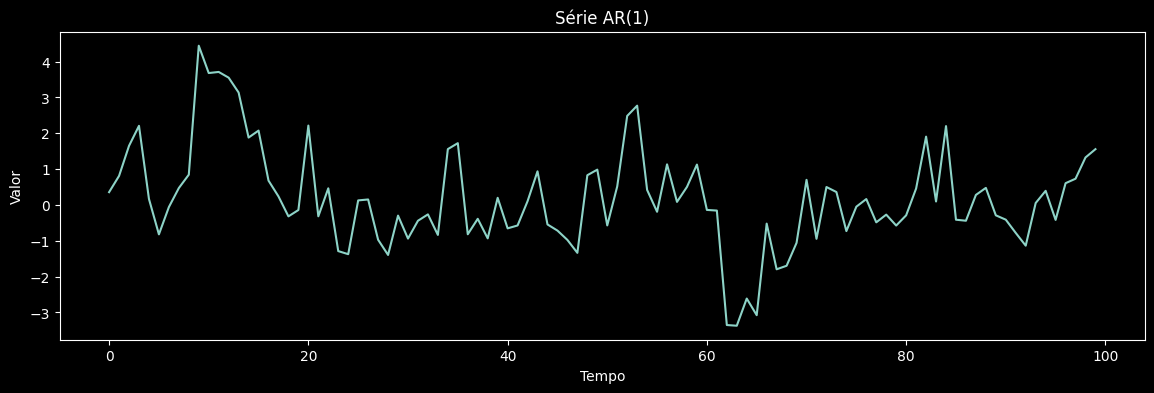

In [5]:
# Simulação de AR(1)
# AR(1): X_t = 0.7 * X_{t-1} + erro 
ar_params = np.array([1, -0.7]) # sinal invertido na convenção
ma_params = np.array([1])

arma_process = ArmaProcess(ar_params, ma_params)
serie_ar = arma_process.generate_sample(nsample=100)

plt.figure(figsize=(14, 4))
plt.plot(serie_ar)
plt.title("Série AR(1)")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.show()

## Modelo MA (Média Móvel)

No modelo MA(q), o valor atual depende de erros passados.

Exemplo MA(1):

#### $X_t = \epsilon_t + \theta * \epsilon_{t-1}$

Onde:
- $\theta$ é o parâmetro
- $\epsilon$ é o ruído branco

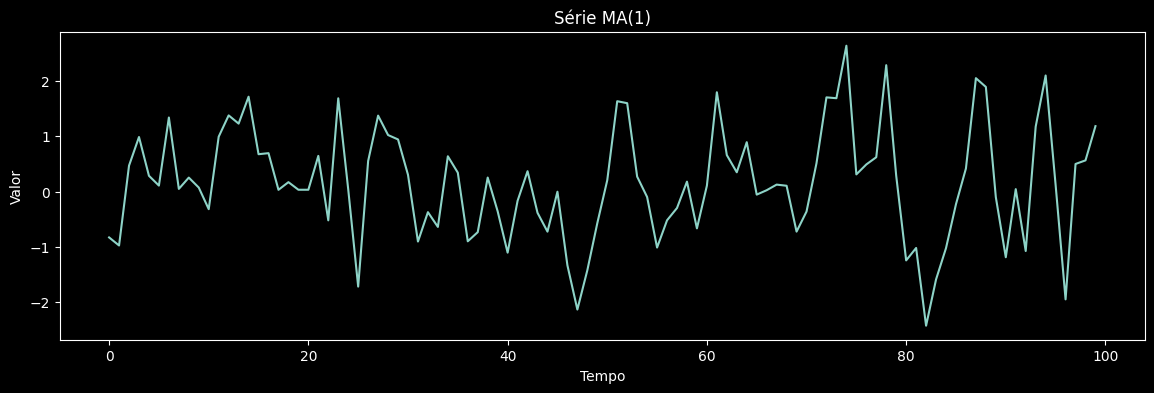

In [6]:
# Simulação de MA(1)
ar_params = np.array([1])
ma_params = np.array([1, 0.5])

arma_process = ArmaProcess(ar_params, ma_params)
serie_ma = arma_process.generate_sample(nsample=100)

plt.figure(figsize=(14, 4))
plt.plot(serie_ma)
plt.title("Série MA(1)")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.show()

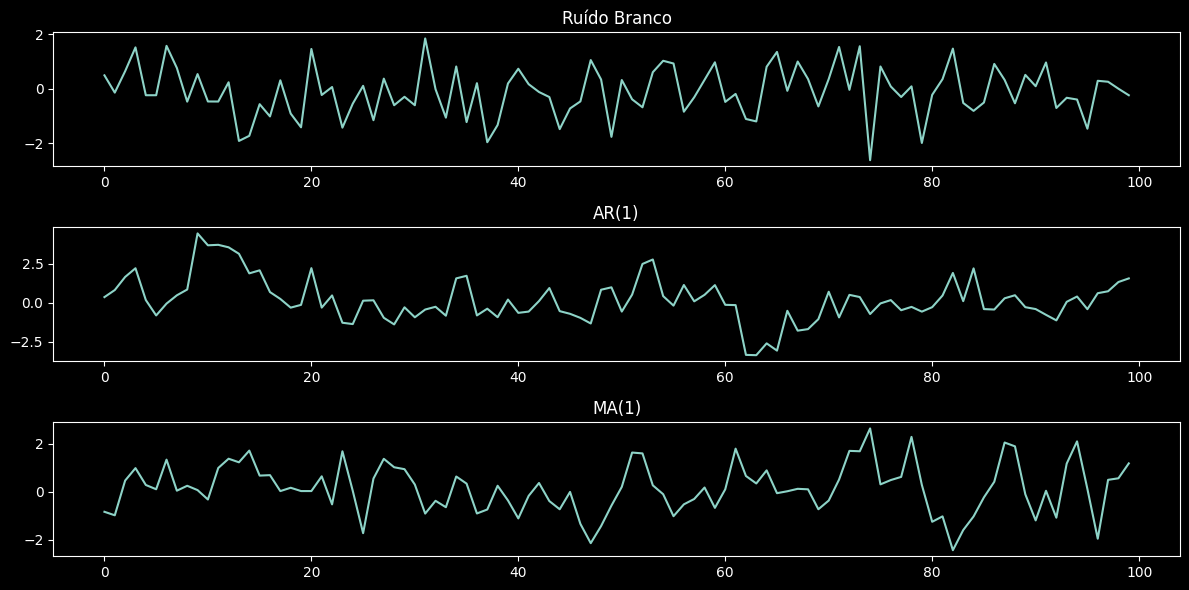

In [7]:
#Comparação Visual
plt.figure(figsize=(12,6))

plt.subplot(3, 1, 1)
plt.plot(serie_ruido)
plt.title("Ruído Branco")

plt.subplot(3, 1, 2)
plt.plot(serie_ar)
plt.title("AR(1)")

plt.subplot(3, 1, 3)
plt.plot(serie_ma)
plt.title("MA(1)")

plt.tight_layout()
plt.show()


## Conclusão 

Neste notebook, aprende-se:

- O que são séries temporais
- Diferença entre séries estacionárias e não estacionárias
- Como testar estacionariedade com ADF
- Como funcionam modelos AR e MA
- Como Simular séries temporais em Python

Esse conceitos são a base para modelos mais avançados como:
- ARIMA
- VAR
- VARMAX

No próximo Notebook, avnaça-se para:
➡️ Modelos ARIMA e diferenciação